![RMIT logo](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTlAppozhCGl50pjgEZu_tTmalWJi3TjpNwCg&s)
|Course|Foundations of Artificial Intelligence for STEM|
|-----|-------|
|Course Code|COSC2968/COSC3053|
|Lecturer(s)|Mr.Nhat-Quang Tran and Mrs.Anh Le Van|
|Full name - Student ID| Le Kim Quyen - s3983370<br>Ton Dat Toan - s4070286<br>Nguyen Hong Ha - s3979100<br>Huynh Bao Khoa Dang - s4045607<br>Nguyen Viet Ngan Anh - s4103086|

# Predicting The Age of Abalone

## Table of Contents
[1. Introduction](#intro) \
&emsp;[1.1. Overview](#intro_1) \
[2. Exploration Data Analysis (EDA)](#eda) \
&emsp;[2.1. Import Libraries and Modules](#eda_1) \
&emsp;[2.2. Load the dataset](#eda_2) \
&emsp;[2.3. Descriptive statistics, visualizations and correlation analysis](#eda_3) \
[3. Data Preprocessing](#data_preprocessing) \
&emsp;[3.1. Remove unused features](#data_preprocessing_1) \
&emsp;[3.2. Identify and handle outliers](#data_preprocessing_2) \
&emsp;[3.3. Split the data](#data_preprocessing_3) \
&emsp;[3.4. Separate labels from data](#data_preprocessing_4) \
&emsp;[3.5. Handle missing values](#data_preprocessing_5) \
&emsp;[3.6. Encode categorical features](#data_preprocessing_6) \
&emsp;[3.7. Scale numerical features](#data_preprocessing_7) \
[4. Model Training and Evaluation](#train_evaluate) \
&emsp;[4.1. Define support Functions](#train_evaluate_1) \
&emsp;&emsp;[4.1.1. R-squared (R2) and root mean squared error (RMSE) Function](#train_evaluate_1_1) \
&emsp;&emsp;[4.1.2. Function to store models](#train_evaluate_1_2) \
&emsp;[4.2. Training Models](#train_evaluate_2) \
&emsp;&emsp;[4.2.1. LinearRegression model](#train_evaluate_2_1) \
&emsp;&emsp;[4.2.2. DecisionTreeRegressor model](#train_evaluate_2_2) \
&emsp;&emsp;[4.2.3. RandomForestRegressor model](#train_evaluate_2_3) \
&emsp;&emsp;[4.2.4. ElasticNet model](#train_evaluate_2_4) \
&emsp;&emsp;[4.2.5. Gradient Boosting Regressor model](#train_evaluate_2_5) \
&emsp;&emsp;[4.2.6. Lasso model](#train_evaluate_2_6) \
&emsp;[4.3. Evaluate with K-fold cross validation](#train_evaluate_3) \
[5. Hyperparameter Fine-tuning](#hyperparameter) \
[6. Model Testing and Analysis](#test_anal) \
[7. References](#ref) \
[8. Contribution](#contribution)

## 1. Introduction <a class="anchor" id="intro"></a>

### 1.1. Overview <a id="intro_1"></a> 

&emsp;Abalones are not only a rich source of nutrition but also provide therapeutic benefits to various diseases such as asthma, atherosclerosis, and heart disease (Suleria et al., 2017). Therefore, it has become one of the most sought-after luxury dishes in some global markets, such as Chile, France, China, Japan, Korea and Vietnam. The high demand for this item has led to an upsurge in the number of abalone farms and fisheries over the past few decades. Because of a potentially abundant supply, reducing costs is essential to keep the products competitive in the market (Cook, 2023). Although the value of abalone and its age have a positive correlation, the old method to determine its age is still slow, expensive and inefficient. Traditionally, an abalone shell must be sliced through the cone, stained, and examined under a microscope to count the rings, each of which represents one year of the abalone. Some rings can be difficult to distinguish, so the estimated age is often multiplied by 1.5 (Akanda et al., 2023). Therefore, it is necessary to implement a new technology to streamline the age-determination process. 

&emsp;The goal of this research is to construct a regression model that estimates the age of abalone just from its physical characteristics, namely, Sex, Length, Diameter, Height, Whole weight, Shucked weight, Viscera weight, and Shell weight. This can help reduce the processing time and cost in abalone production. This report will consider six machine learning models, namely, linear regression model, decision tree regressor model, random forest regressor model, elastic net model, gradient boosting regressor, and lasso model, to find the optimal method. R-squared (R²) and Root Mean Squared Error (RMSE) are used to evaluate the models. 

*Write something here*

## 2. Exploration Data Analysis (EDA) <a class="anchor" id="eda"></a>

### 2.1. Import libraries and modules <a id="eda_1"></a>
Installing and getting started with Terminal (if necessary):
+ pip install matplotlib
+ pip install seaborn
+ pip install ydata-profiling
+ pip install ipywidgets
+ pip install scikit-learn
+ pip install setuptools

To install the necessary libraries / modules such as `pandas` [ref] for read dataset; `matplotlib` [ref], `seaborn` [ref] and `ydata` [ref] for visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
from statistics import mean

# run plots inline
%matplotlib inline

### 2.2. Load the dataset <a id="eda_2"></a>

In [3]:
abalone_df = pd.read_csv('Documents/Datasets/abalone.csv')
abalone_df.head() # Shows the first five samples

,Type,LongestShell,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


**Dataset description** 

&emsp;The dataset on abalone by Nash et al. (1995) was chosen due to several reasons. Firstly, in machine learning, particularly data analysis where datasets can range up to millions of samples, our chosen dataset is considered relatively moderate with a sample size of 4177, making it applicable in real-world scenarios. Secondly, there are eight different features, including one categorical feature, Type, and seven numeric features: Length, Diameter, Height, Whole weight, Shucked weight, Viscera weight, and Shell weight. It also has 'rings' variable as the target data. The diversity in the number and dimensions makes the dataset satisfactory to the proposed regression model. 

&emsp;Based on the original study of this dataset (Nash et al., 1994), and the statistics of Candy Abalone (2021), there are some inconsistencies between the unit in the dataset (using decimeter and hectogram) and the description (millimetre and gram) on the latter version of Nash et al. (1995). Therefore, while the program runs the data in decimeter and hectogram, the report will interpret data using millimetre and gram for consistency with other reports, research, and accessibility to general readers.

*Catagorical Variable:* 
+ `Type`: Type of abalones (M = male, F = female and I = infant) 
 
*Numerical Variables:* 
+ `Length`: The longest shell measurement in mm 
+ `Diameter`: The perpendicular to the length in mm 
+ `Height`: The height with meat in shell in mm 
+ `Whole weight`: The total weight of the abalone in g 
+ `Shucked weight`: The weight of the edible meat portion of the abalone in g 
+ `Viscera weight`: The weight of the abalone's internal organs, specifically the gut, after bleeding in g 
+ `Shell weight`: The weight of the shell after being dried in g 
+ `Rings`: +1.5 gives the age of the abalone in years 

In [ ]:
abalone_df.info() # Shows overview of each feature

&emsp;There are 4177 samples with no missing values. There are totally 9 variables, including 1 label (rings), and 8 features. While 'type' variable is categorical, and 'rings' variable is discrete, the rest are continuous data.

### 2.3. Descriptive statistics, visualizations and correlation analysis <a id="eda_3"></a>

**An overview using ydata** [ref]**:**

In [ ]:
# An overview using ydata
ydata = ProfileReport(abalone_df, title = 'Abalone overview')
ydata.to_notebook_iframe()
ydata.to_file('Documents/Figures/abalone.html')

&emsp;Abalones are categorized into 3 groups: female, male, and infant. The male group is comprised of 36.6% of the total samples (n = 1528), slightly larger than 2 other groups. Meanwhile, the infant and female groups have approximately the same sample size, at 32.1% (n = 1342) and 31.3% (1307). 

&emsp;Generally, descriptive statistics indicate the average size of all abalone samples with the length of 52.4 mm (*SD* = 12), the diameter of 40 mm (*SD* = 9.92), and the height of 13.9 mm (*SD* = 4.18). The average whole weight is at 82.8 g (*SD* = 49), including the shucked weight of 35.9 g (*SD* = 22.19), the viscera weight of 18 g (*SD* = 10.96), and the shell weight of 23.9 g (*SD* = 13.92). The abalone are reported to be aged at nearly 10 years (*SD* = 3.22) on average.Regarding distribution, the histograms show that no variance of any variables follows normal distribution. The histogram of height might be affected by two extreme values on the right and two error value (= 0) on the left. Meanwhile, the other might be due to the limited cover of the sample size. According the scale of Pearson correlation coefficients (Selvanathan et al., 2020), the number of rings has a moderate positive correlation with each feature, with *p* values ranging from 0.42 to 0.57.

In [86]:
# Create an empty dataframe to contain min_max value for each type
df = pd.DataFrame(data = {})

# remove 3 columns
remove_df = abalone_df.drop(['ShuckedWeight', 'VisceraWeight', 'ShellWeight'], axis = 1, inplace = False)

# Create columns for new dataframe
for col in remove_df.columns:
    if col != 'Type':
        df[f'{col}_min'] = [0]
        df[f'{col}_max'] = [0]
        
# Loop each type (M, F, I)
for i, type in enumerate(list(remove_df['Type'].unique())):
    type_df = remove_df.loc[remove_df['Type'] == type] # get dataframe for each type
    array = np.array([]) # create an empty array to contain each min_max values
    for col in type_df.columns:
        if col != 'Type':
            array = np.concatenate((array, np.array([np.min(type_df[col])])))
            array = np.concatenate((array, np.array([np.max(type_df[col])])))
    df.loc[i] = None # fix FutureWarning
    df.loc[i] = array # set value for each type
    
df.index = list(abalone_df['Type'].unique()) # rename index from [0, 1, 2] to ['M', 'F', 'I']
df

,LongestShell_min,LongestShell_max,Diameter_min,Diameter_max,Height_min,Height_max,WholeWeight_min,WholeWeight_max,Rings_min,Rings_max
M,0.155,0.780,0.110,0.63,0.025,0.515,0.0155,2.8255,3.0,27.0
F,0.275,0.815,0.195,0.65,0.015,1.130,0.0800,2.6570,5.0,29.0
I,0.075,0.725,0.055,0.55,0.000,0.220,0.0020,2.0495,1.0,21.0


**Scatter plot between every pair of feature using seaborn** [ref]**:**

In [ ]:
# An overview of the relationship between each pair feature
sns.set_theme() # set default theme for plot

# Plot features with each color for each type of abalone, including male (M), female (F) and infant (I)
sns.pairplot(data = abalone_df, hue = 'Type', corner = True, palette = 'Set2');

plt.savefig('Documents/Figures/pairplot.png') # save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

**Compute correlations between features**

In [ ]:
# The variable contains correlations between features
abalone_corr = abalone_df.corr(numeric_only = True)

# uncomment to see data as table
# abalone_corr

**Visualize using headmap from seaborn** [ref]**:**

In [ ]:
ones_corr = np.ones_like(abalone_corr, dtype = bool) # create a matrix contains boolean values with the same shape as abalone_corr
mask = np.triu(ones_corr) # a mask contains half triangle matrix of True and False

# Remove redundant the first row and the last column
adjusted_abalone_corr = abalone_corr.iloc[1:, :-1]
adjusted_mask_corr = mask[1:, :-1]

# Create plot
fig, ax = plt.subplots(figsize = (10, 8))

# Show heatmap
sns.heatmap(data = adjusted_abalone_corr, mask = adjusted_mask_corr, cmap = 'Blues',
            annot = True, fmt = '.2f', vmin = -1, vmax = 1,
            linecolor = 'white', linewidths = .5, annot_kws = {'fontsize': 14});

plt.savefig('Documents/Figures/heatmap.png') # Save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

**Distribution of Numerical feature values**

In [16]:
abalone_df.describe()

,LongestShell,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [ ]:
abalone_df.hist(figsize=(10,15))
plt.savefig('Documents/Figures/histmap.png')
plt.show()

*Write something? Q - idk*

**Distribution of Categorical feature values**

In [14]:
abalone_df.describe(include = 'object')

,Type
count,4177
unique,3
top,M
freq,1528


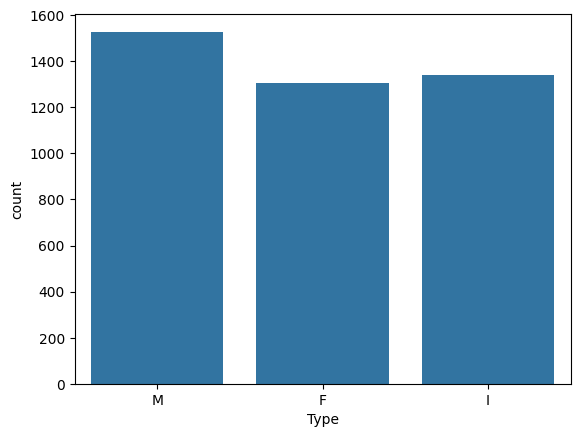

In [15]:
sns.countplot(data = abalone_df, x = 'Type');

*Write something? Q - idk*

**The relationship between LongestShell and Rings using jointplot from seaborn** [ref]**:**

In [ ]:
sns.jointplot(data = abalone_df, x = 'LongestShell', y = 'Rings', hue = 'Type');

plt.savefig('Documents/Figures/longestshell_rings.png') # Save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

**The relationship between Diameter and Rings using FacetGrid from seaborn** [ref]**:**

In [ ]:
abalone_fg = sns.FacetGrid(data = abalone_df, col = 'Type')
abalone_fg.map(sns.scatterplot, 'Diameter', 'Rings', alpha = .4);

plt.savefig('Documents/Figures/diameter_rings.png') # Save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

**The relationship between Height and Rings using FaceGrid from seaborn** [ref]**:**

In [ ]:
abalone_fg = sns.FacetGrid(data = abalone_df, col = 'Type')
abalone_fg.map(sns.scatterplot, 'Height', 'Rings', alpha = .4);

plt.savefig('Documents/Figures/height_rings.png') # Save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

**The relationship between WholeWeight and Rings using jointplot from seaborn** [ref]**:**

In [ ]:
sns.jointplot(data = abalone_df, x = 'WholeWeight', y = 'Rings', hue = 'Type');

plt.savefig('Documents/Figures/wholeweight_rings.png') # Save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

## 3. Data Preprocessing <a id="data_preprocessing"></a>

### 3.1. Remove unused features <a id="data_preprocessing_1"></a>

In [11]:
abalone_df.drop(columns = ['ShuckedWeight', 'VisceraWeight', 'ShellWeight'], inplace = True)
# Uncomment to see the outcome
abalone_df

,Type,LongestShell,Diameter,Height,WholeWeight,Rings
0,M,0.455,0.365,0.095,0.5140,15
1,M,0.350,0.265,0.090,0.2255,7
2,F,0.530,0.420,0.135,0.6770,9
3,M,0.440,0.365,0.125,0.5160,10
4,I,0.330,0.255,0.080,0.2050,7
...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,11
4173,M,0.590,0.440,0.135,0.9660,10
4174,M,0.600,0.475,0.205,1.1760,9
4175,F,0.625,0.485,0.150,1.0945,10


&emsp; As mentioned above, the distribution, and the correlation with the ring number are almost similar for the whole weight, the shucked weight, viscera weight, and shell weight, which might lead to unnecessary duplication when analysing data. The whole weight is measured when the intact abalone has not dried, so it consists of the shucked weight, the viscera weight, the shell weight, and the weight of retained water in the abalone. Therefore, to make it more concise, the whole weight will be retained while the others are removed.

### 3.2. Identify and handle outliers <a id="data_preprocessing_2"></a>
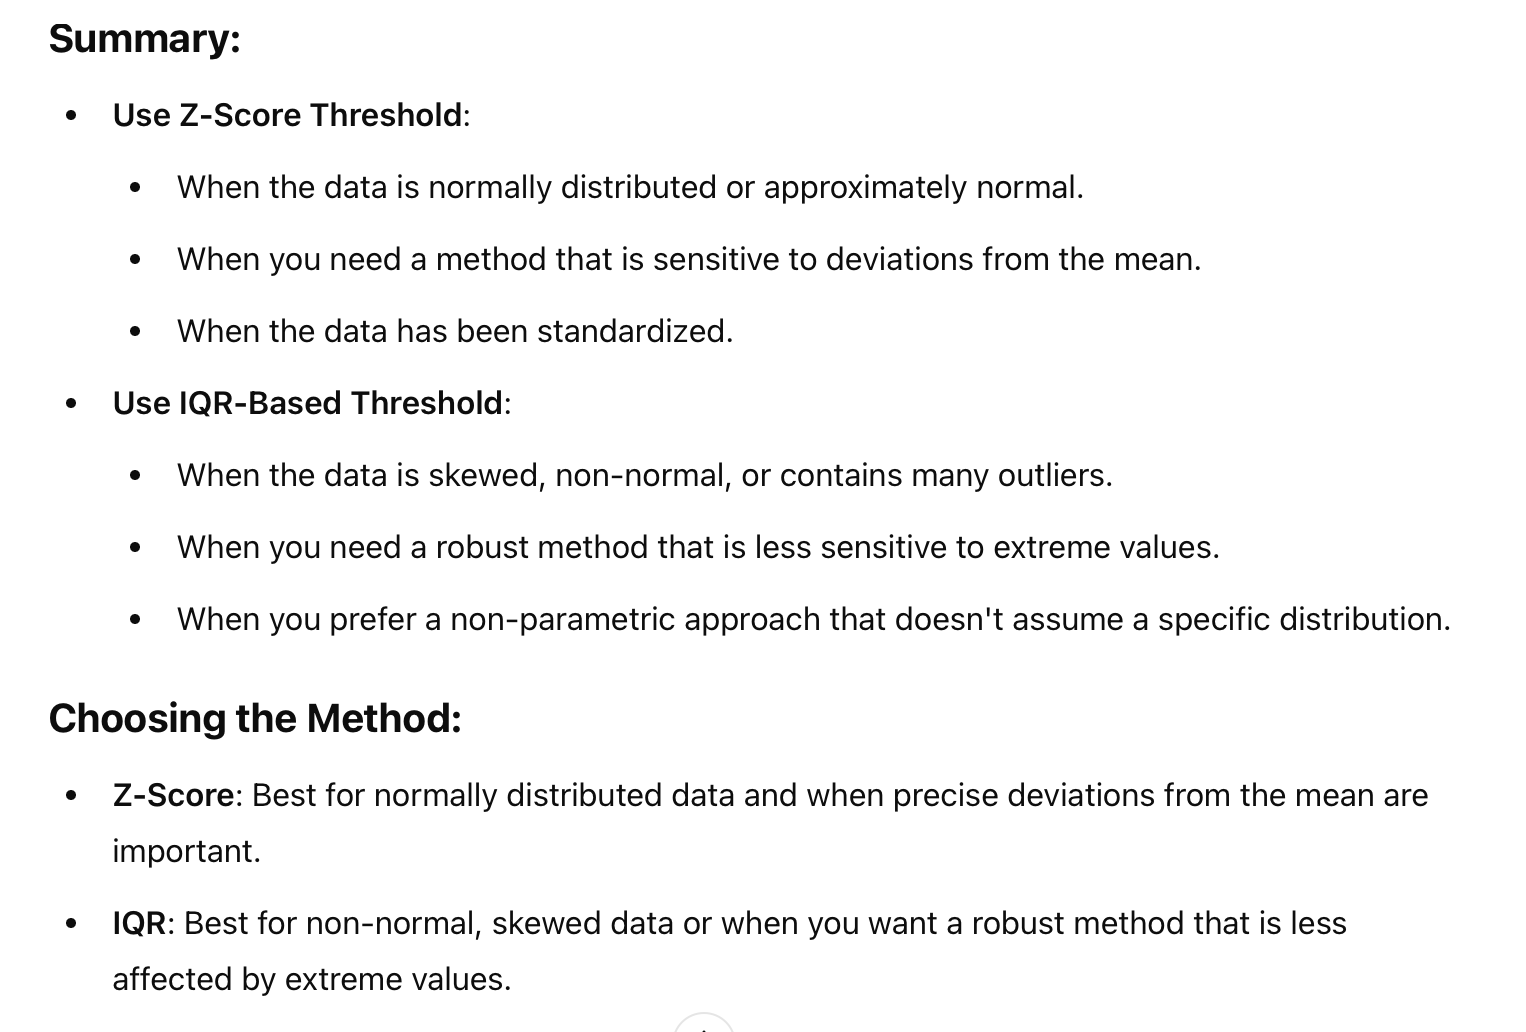 \
prompt chatGPT: "When to use Z-Score Threshold, when to use IQR-Based Threshold and how to use?"

In [12]:
cal = 'iqr'

total_rows = abalone_df.shape[0] # number of rows
new_total_rows = 0 # number of rows after filter

# Use Z-Score Threshold
while (new_total_rows != total_rows): # when equal => no more outlier values
    total_rows = abalone_df.shape[0]
    
    for col in abalone_df.columns: # loop through each column
        if col != 'Type':
            if cal == 'z-score':
                threshold = 3 # set ThresHold
                mean_num = np.mean(abalone_df[col]) # calculate mean
                std_num = np.std(abalone_df[col]) # calculate standard deviation
                
                # Identify z-score
                z_high = 3 * std_num + mean_num
                z_low = mean_num - 3 * std_num
                
                # Finding index that is outlier
                index_outliers = abalone_df.loc[(abalone_df[col] > z_high) | (abalone_df[col] < z_low) | (abalone_df[col] == 0)].index
            else:
                q1, q3 = np.percentile(abalone_df[col], [25, 75])
                iqr = q3 - q1
                lower_bound = q1 - 1.5 * iqr
                upper_bound = q3 + 1.5 * iqr

                # Finding index that is outlier
                index_outliers = abalone_df.loc[(abalone_df[col] > upper_bound) | (abalone_df[col] < lower_bound) | (abalone_df[col] == 0)].index

            # Drop that row
            abalone_df.drop(index_outliers, inplace = True) # inplace = True => renew data
            
    new_total_rows = abalone_df.shape[0]
    # print(total_rows, new_total_rows, '\n')

4177 3821 

3821 3812 

3812 3812 



### 3.3. Split the data <a id="data_preprocessing_3"></a>

In [11]:
from sklearn.model_selection import train_test_split

# Split the raw data: abalone_train (80%) for training and abalone_test (20%) for testing with the percentage
abalone_train, abalone_test = train_test_split(abalone_df, test_size = 0.2, random_state = 25)

# Uncomment to se the outcome
# abalone_train.shape, abalone_test.shape

### 3.4. Separate labels from data <a id="data_preprocessing_4"></a>
Choosing "Rings" column as the label.

In [12]:
# Split train set
train_set_labels = abalone_train['Rings'].copy()
train_set = abalone_train.drop(columns = 'Rings', inplace = False)

# Split test set
test_set_labels = abalone_test['Rings'].copy()
test_set = abalone_test.drop(columns = 'Rings', inplace = False)

*Write something? Q - idk*

### 3.5. Handle missing values <a id="data_preprocessing_5"></a>
There is no missing values to handle?? 😢 \
`mean`: The average value \
`median`: The mid point value \
link: https://www.w3schools.com/python/python_ml_mean_median_mode.asp

In [13]:
from sklearn.impute import SimpleImputer

# Handle missing values in train_set and test_set
for i, set in enumerate([train_set, test_set]):
    # if i == 0:
    #     print('____________ Training set ____________')
    # else:
    #     print('____________ Testing set ____________')

    for col in set.columns:
        missing_values = set[col].isna().sum() # count number of missing values existed in a column
        if missing_values > 0:
            if col != 'Type': # find the nan values and replace by median number for numerical features
                imp_median = SimpleImputer(missing_values = np.nan, strategy = 'median')
                set[col] = imp_median.fit_transform(set[col].values.reshape(-1, 1))[:, 0]
            else: # find the nan values and replace by 'Unknown' string for categorical feature
                imp_type = SimpleImputer(missing_values = np.nan, strategy = 'constant', fill_value = 'Unknown')
                set[col] = imp_type.fit_transform(set[col].values.reshape(-1, 1))[:, 0]
            
    #     print(f'Feature {col} has {missing_values / len(set) * 100}% missing values')
    # print('')

# Handle missing value in labels
for i, label in enumerate([train_set_labels, test_set_labels]):
    if i == 0:
        set = 'training set'
    else:
        set = 'testing set'

    missing_values = label.isna().sum()
    if missing_values > 0:
        imp_median = SimpleImputer(missing_values = np.nan, strategy = 'median')
        label = imp_median.fit_transform(label.values.reshape(-1, 1))[:, 0]
    # print(f'Label Rings in {set} has {missing_values / len(label) * 100}% missing values')

*Write something? Q - idk*

### 3.6. Encode categorical features <a id="data_preprocessing_6"></a>
There is one categorical feature in the dataset need to be encoded: `Type`

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create a class for encode columns
colTrans = ColumnTransformer(transformers = [('encode', OneHotEncoder(), [0])], remainder = 'passthrough')

# Encode
train_set = colTrans.fit_transform(train_set)
# train_set[0]
test_set = colTrans.transform(test_set)
# test_set[0]

In [15]:
# Transform label column sets into the same format (array) with the above sets
train_set_labels = train_set_labels.values
test_set_labels = test_set_labels.values

### 3.7. Scale numerical features <a id="data_preprocessing_7"></a>
Scale features to zero mean and unit variance.

In [16]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

# Just only scale numerical features in training and testing set, not category feature
train_set[:, 3:] = std_scaler.fit_transform(train_set[:, 3:])
test_set[:, 3:] = std_scaler.transform(test_set[:, 3:])

## 4. Model Training and Evaluation <a id="train_evaluate"></a>

**Note:**
+ `train_set` contains set data for training
+ `train_set_labels` contains labels for training
+ `test_set` contains set data for testing
+ `test_set_labels` contains labels for testing

**Modules in lec:**
+ LinearRegression
+ DecisionTreeRegressor
+ RandomForestRegressor
+ PolynomialFeatures

### 4.1. Define support functions <a id="train_evaluate_1"></a>

#### 4.1.1. R-squared (R2) and root mean squared error (RMSE) function <a id="train_evaluate_1_1"></a>

In [ ]:
from sklearn.metrics import mean_squared_error

def r2score_and_rmse(model, train_data, labels): 
    r2score = model.score(train_data, labels)
    prediction = model.predict(train_data)
    mse = mean_squared_error(labels, prediction)
    rmse = np.sqrt(mse)
    return r2score, rmse

#### 4.1.2. Functions to store and load models <a id="train_evaluate_1_2"></a>
Parameters:
+ `action`: to distinguish between models training and models evaluation
+ `model`: model
+ `model_name`: name of model

In [ ]:
import joblib # new lib

def store_model(action, model, model_name = ''):
    # NOTE: sklearn.joblib faster than pickle of Python
    # INFO: can store only ONE object in a file
    if model_name == '': 
        model_name = type(model).__name__
    joblib.dump(model,f'Documents/Models/{model_name}_model_{action}.pkl')

def load_model(action, model_name):
    # Load objects into memory
    #del model
    model = joblib.load(f'Documents/Models/{model_name}_model_{action}.pkl')
    #print(model)
    return model

### 4.2. Training models <a id="train_evaluate_2"></a>

#### 4.2.1. LinearRegression model <a id="train_evaluate_2_1"></a>

In [ ]:
from sklearn.linear_model import LinearRegression

# Create an empty model
model = LinearRegression()
model_name = model.__class__.__name__

# Call function to training model
model.fit(train_set, train_set_labels)
print(f'\n____________ {model_name} ____________')

# Compute R2 score and root mean squared error
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')
        
# Predict labels for some training instances (9 first samples)
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model_name)

*Write something? Q - idk*

#### 4.2.2. DecisionTreeRegressor model <a id="train_evaluate_2_2"></a>

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Create an empty model
model = DecisionTreeRegressor()
model_name = model.__class__.__name__

# Training model
model.fit(train_set, train_set_labels)

# Compute R2 score and root mean squared error
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)

print('\n____________ DecisionTreeRegressor ____________')
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')

# Predict labels for some training instances (the first 9 samples)
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model)

*Write something? Q - idk*

#### 4.2.3. RandomForestRegressor model <a id="train_evaluate_2_3"></a>

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create an empty model
model = RandomForestRegressor()
model_name = model.__class__.__name__

# Training model
model.fit(train_set, train_set_labels)

# Compute R2 and RMSE
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)

print('\n____________ RandomForestRegressor ____________')
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')

# Predict the first 9 samples
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model)

*Write something? Q - idk*

#### 4.2.4. ElasticNet model <a id="train_evaluate_2_4"></a>

In [ ]:
from sklearn.linear_model import ElasticNet

# Create Elastic net model
model = ElasticNet()
model_name = model.__class__.__name__

# Train the model 
model.fit(train_set, train_set_labels)

# Compute R2 and RMSE
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)

print('\n____________ ElasticNet ____________')
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')

# Predict the first 9 samples
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model)


*Write something? Q - idk*

#### 4.2.5. Gradient Boosting Regressor <a id="train_evaluate_2_5"></a>
`n_estimators` : the number of boosting stages that will be performed. Later, we will plot deviance against boosting iterations.

`max_depth` : limits the number of nodes in the tree. The best value depends on the interaction of the input variables.

`min_samples_split` : the minimum number of samples required to split an internal node.

`learning_rate` : how much the contribution of each tree will shrink.

`loss` : loss function to optimize. The least squares function is used in this case however, there are many other options

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Create the model
params = {
    "n_estimators": 500,
    "max_depth": 4,
    "min_samples_split": 5,
    "learning_rate": 0.01,
    "loss": "squared_error",
}
model = GradientBoostingRegressor(**params)
model_name = model.__class__.__name__

# Train the model
model.fit(train_set, train_set_labels)

# Compute R2 and RMSE
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)

print('\n____________ GradientBoostingRegressor ____________')
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')

# Predict the first 9 samples
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model)


*Write something? Q - idk*

#### 4.2.6. Lasso model <a id="train_evaluate_2_6"></a>

In [ ]:
from sklearn.linear_model import Lasso

# Create the model
model = Lasso(alpha=0.1)
model_name = model.__class__.__name__

# Train the model
model.fit(train_set, train_set_labels)

# Compute R2 and RMSE
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)

print(f'\n____________ {model_name} ____________')
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')

# Predict the first 9 samples
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model)

*Write something? Q - idk*

### 4.3. Evaluate with K-fold cross validation <a id="train_evaluate_3"></a>
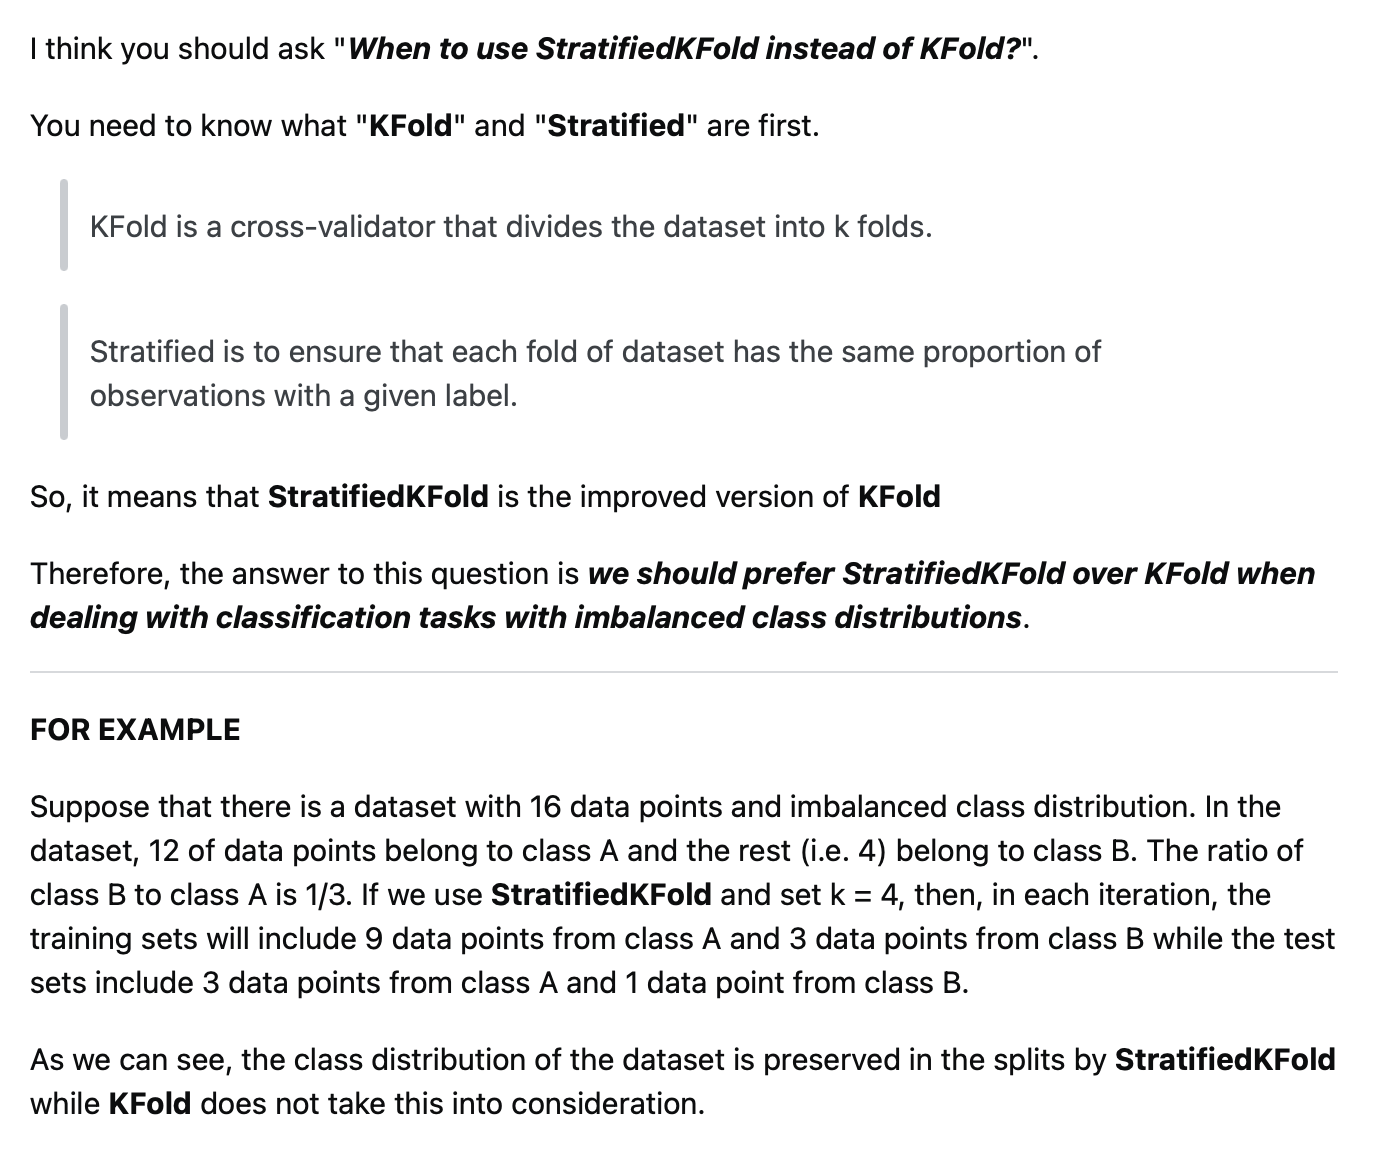 \
link: https://stackoverflow.com/questions/65318931/stratifiedkfold-vs-kfold-in-scikit-learn \
**Lec:** "KFold randomly splits data, hence does NOT ensure data splits are the same (only StratifiedKFold may ensure that)" \
=> The answer for using K-fold instead of StratifiedKFold for our training


I think the categorical feature (`Type`) is not much that *imbalanced* - Q


*Write something? Q - idk*

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits = 5, shuffle = True, random_state = 25)

# Evaluate LinearRegression
model = LinearRegression()
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 5))}\n')


# Evaluate DecisionTreeRegressor
model = DecisionTreeRegressor()
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 5))}\n')


# Evaluate RandomForestRegressor
model = RandomForestRegressor()
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 5))}\n')


# Evaluate ElasticNet model
model = ElasticNet()
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 5))}\n')


# Evaluate GradientBoostingRegressor
params = {
    "n_estimators": 500,
    "max_depth": 4,
    "min_samples_split": 5,
    "learning_rate": 0.01,
    "loss": "squared_error",
}
model = GradientBoostingRegressor(**params)
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 5))}\n')


# Evaluate Lasso model
model = Lasso(alpha = .1)
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 5))}\n')

## 5. Hyperparameter Fine-tuning <a id="hyperparameter"></a>
"Random search is generally more efficient when the hyperparameter space is large and the optimal hyperparameters are not highly correlated, whereas grid search is more efficient when the hyperparameters are highly correlated and have a strong interaction effect." Link: https://360digitmg.com/blog/comparison-gridsearchcv-and-randomsearchcv#:~:text=Random%20search%20is%20generally%20more,have%20a%20strong%20interaction%20effect.

Now we will try to make the model more accurate, reduce the rmse score by tuning the parameters \
We chose `GradientBoostingRegresorr` based on its Avg. rmse is the lowest.

### 5.1. Support function <a id="hyperparameter_1"></a>
Function to print the output for fine-tune.

In [ ]:
def print_search_result(search, model_name = ""): 
    print("\n====== Fine-tune " + model_name +" ======")
    print('Best hyperparameter combination: ',search.best_params_)
    print('Best rmse: ', np.sqrt(-search.best_score_))  
    #print('Best estimator: ', grid_search.best_estimator_) # NOTE: require refit=True in  SearchCV
    # print('Performance of hyperparameter combinations:')
    # cv_results = search.cv_results_
    # for (mean_score, params) in zip(cv_results["mean_test_score"], cv_results["params"]):
    #     print('rmse =', np.sqrt(-mean_score), params) 

Choose a search here

In [ ]:
method = 2 
# 1 for grid search, 2 for randomized search

### 5.2. Grid search <a id="hyperparameter_2"></a>

In [ ]:
if method == 1:
    from sklearn.model_selection import GridSearchCV
    cv = KFold(n_splits=3,shuffle=True,random_state=25) # cv data generator
        
    run_new_search = 0  # Set to 1 to run new search
    if run_new_search:        
        
        # 5.1.1 Fine-tune GradientBoostingRegressor, since it is the best model
        model = GradientBoostingRegressor()
        model_name = model.__class__.__name__
        param_grid = {
            # try combinations of parameters

            'n_estimators': [50, 100, 150],  # numbers of trees built
            # higher the more trees builts, improve performace but may lead to overfitting

            'learning_rate': [0.01, 0.05, 0.1],  # Shrinkage of the contribution of trees
            # how much a tree can contribute, lower mean each tree contribute less, but make the model more accurate, for the cost of learning time

            'max_depth': [1, 3, 5],  # max depth of each tree
            # max depth for each tree, can capture more complex pattern, but can lead to overfitting
            
            'min_samples_split': [2, 5, 10],   # min numbers of samples required to split an internal node
            # Higher value prevent spliting nodes, prevent overfitting

            'min_samples_leaf': [1, 2, 4], # min numbers of samples to be at a leaf node
            # Ensure each leaf has enough sample, preventing leaves with too few samples

            'subsample': [0.6, 0.7, 1.0], # split sample for fitting into tree
            # less mean more trees, improbing generalization, but requires more trees.
            'max_features': [0.2, 0.5, 0.7]  # numbers of features to consider when looking for the best split
            # Add randomness in the tree building process. Ex: 0.2 of total features, 1 is all features
            }
            # Train cross 5 folds, hence a total of (37500)*5=187500 rounds of training 
        grid_search = GridSearchCV(model, param_grid, cv=cv, scoring='neg_mean_squared_error', n_jobs=8, verbose=10, 
                                   refit=True) # refit=True: after finding best hyperparam, it fit() the model with whole data (hope to get better result)
        
        # Start fitting to find best model
        grid_search.fit(train_set, train_set_labels)
        store_model('grid_search', grid_search, model_name)
        print_search_result(grid_search, model_name)
    else: # If don't run new search
        fitted_models = load_model('grid_search', 'GradientBoostingRegressor')
        print(fitted_models.best_estimator_)

### 5.3 Randomized search



In [ ]:
if method == 2:
    from sklearn.model_selection import RandomizedSearchCV
    from scipy.stats import randint, uniform  # To make continuous range of numbers for randomized search
    cv = KFold(n_splits=5,shuffle=True,random_state=25) # cv data generator
        
    run_new_search = 0 # Set to 1 to run new search
    if run_new_search:        
        
        # 5.1.1 Fine-tune GradientBoostingRegressor, since it is the best model
        model = GradientBoostingRegressor()
        model_name = model.__class__.__name__
        param_distributions = {
            # try random combinations of range of parameters

            'n_estimators': randint(50, 500),  # numbers of trees built
            # higher the more trees builts, improve performace but may lead to overfitting

            'learning_rate': uniform(0.01, 0.19),  # Shrinkage of the contribution of trees
            # how much a tree can contribute, lower mean each tree contribute less, but make the model more accurate, for the cost of learning time

            'max_depth': randint(1, 10),  # max depth of each tree
            # max depth for each tree, can capture more complex pattern, but can lead to overfitting
            
            'min_samples_split': randint(2, 20),   # min numbers of samples required to split an internal node
            # Higher value prevent spliting nodes, prevent overfitting

            'min_samples_leaf': randint(1, 10), # min numbers of samples to be at a leaf node
            # Ensure each leaf has enough sample, preventing leaves with too few samples

            'subsample': uniform(0.3, 0.7), # split sample for fitting into tree
            # less mean more trees, improbing generalization, but requires more trees.
            'max_features': ['sqrt', 'log2']  # numbers of features to consider when looking for the best split
            # Add randomness in the tree building process. Ex: 0.2 of total features, 1 is all features
            }
            # Train cross 5 folds, hence a total of (37500)*5=187500 rounds of training 
        search = RandomizedSearchCV(model, param_distributions, n_iter=500, cv=cv, scoring='neg_mean_squared_error', random_state=25,
                                    n_jobs=8, verbose=10, return_train_score=True, refit=True) 
        # refit=True: after finding best hyperparam, it fit() the model with whole data (hope to get better result)
        
        # Start fitting to find best model
        search.fit(train_set, train_set_labels)
        store_model('randomized_search', search, model_name)
        print_search_result(grid_search, model_name)
    else: 
        fitted_models = load_model('randomized_search', 'GradientBoostingRegressor')
        print(fitted_models.best_estimator_)

## 6. Model Testing and Analysis <a id="test_anal"></a>

In [ ]:
fitted_models = load_model('randomized_search', 'GradientBoostingRegressor')
best_model = fitted_models.best_estimator_

store_model('best_model', best_model, 'GradientBoostingRegressor')

# Run model with test set
r2score, rmse = r2score_and_rmse(best_model, test_set, test_set_labels)
print('\nPerformance on test data:')
print(f'R2 score (on test data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')
# Predict labels for some test instances
print("\nTest data: \n", abalone_test.iloc[0:9])
print("\nPredictions: ", best_model.predict(test_set[0:9]).round(decimals = 1))
print("Labels:      ", list(test_set_labels[0:9]),'\n')

## 7. References <a id="ref"></a>

## 8. Contribution <a id="contribution"></a>
|Student ID|Student Name|Contribution Rate <br> (1-100%)|Responsible for <br> (Parts, Cells...)|Note|
|------|------|------|------|------|
|s3983370|Le Kim Quyen| | | |
|s4070286|Ton Dat Toan| | | |
|s3979100|Nguyen Hong Ha| | | |
|s4045607|Huynh Bao Khoa Dang| | | |
|s4103086|Nguyen Viet Ngan Anh| | | |